In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [10]:
df = pd.read_csv("../extraction/caregiverRaw.csv", sep=";")

df

,genderId,id,orgRef,dateOfBirth,nationality,maritalStatus,preferredTransport,Betreuer:innen_Bew_Ein_Ja,bew-am,eingestellt-am,...,gewerbeschein_nr,isPaymentBlocked,allgemeine-erfahrung-ausland-dauer,covid-1-wann,covid-2-wann,erfahrung-krankenhaus-abteilung,allgemeine-taetigkeiten-ausland,grund-unpassend,weitere_ausbildungen,fachspezifische-ausbildung-welche
0,F,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,Direktbewerbung,19950804,Rumänien,Verheiratet,Sonstiges,False,2.019071e+13,20190903020000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F,002e16cc-274f-bf74-d123-98b4704b1aab,Team Rumänien,19810731,Rumänien,Verheiratet,Blagoiescu,False,2.025013e+13,20250206010000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F,00411252-62ff-bc52-5ab0-5fbfd476b2a2,Team Rumänien,19710127,Rumänien,Verwitwet,Blagoiescu,False,2.025101e+13,20251016020000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F,004afdff-fff7-9d87-63ae-7273409908bb,ZZ_Palaloga rum.,19680328,Österreich,Geschieden,ZZ_Cotrans,False,2.020013e+13,20200213010000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F,0061dab5-0194-a1a8-5aba-d718f21e2ff7,ZZ_PML Übernahme,19660517,Slowakei,Verwitwet,Selbstfahrer,False,2.022100e+13,20221001020000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7366,F,ffddabef-72ea-967e-dc01-c9edbb211fb7,Team Rumänien,19700303,Rumänien,Ledig,Master Express,False,2.023042e+13,20230425020000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7367,F,ffdde431-8a90-7beb-4330-a7956fb650aa,ZZ_Palaloga rum.,19800428,Rumänien,Ledig,Blagoiescu,False,2.020081e+13,20200818020000,...,NaN,False,NaN,2.021122e+13,2.021122e+13,NaN,NaN,NaN,NaN,NaN
7368,F,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,Direktbewerbung,19640207,Rumänien,Verheiratet,Master Express,False,2.018101e+13,20181023020000,...,NaN,False,NaN,2.021051e+13,2.021051e+13,NaN,NaN,NaN,NaN,NaN
7369,F,ffe47fdd-10cb-ff7b-5190-85f5fff12bd0,Team Ungarn,19681129,Ungarn,Ledig,Selbstfahrer,False,2.019101e+13,20191112010000,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
def eda_summary(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "count": df.count(),
        "missing": df.isna().sum(),
        "missing_%": df.isna().mean() * 100,
        "unique": df.nunique(dropna=True),
    })

    summary["min"] = df.select_dtypes(include="number").min()
    summary["mean"] = df.select_dtypes(include="number").mean()
    summary["median"] = df.select_dtypes(include="number").median()
    summary["max"] = df.select_dtypes(include="number").max()

    return summary.round(2)

summary = eda_summary(df)
summary.to_csv("summary.csv", sep=";")

dtype
bool       75
object     45
float64    19
int64       2
Name: count, dtype: int64

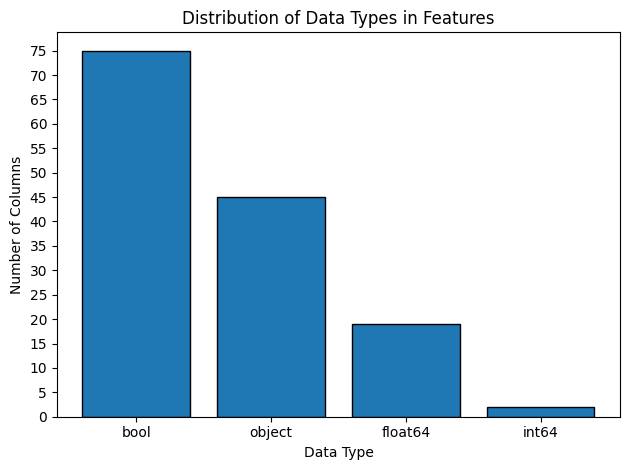

In [28]:
dtypes = summary["dtype"].astype(str).value_counts()

plt.bar(
    dtypes.index,
    dtypes.values,
    edgecolor="black"
)

plt.title("Distribution of Data Types in Features")
plt.xlabel("Data Type")
plt.ylabel("Number of Columns")

plt.yticks(
    np.arange(0, dtypes.max() + 5, 5)
)

plt.tight_layout()
plt.show()

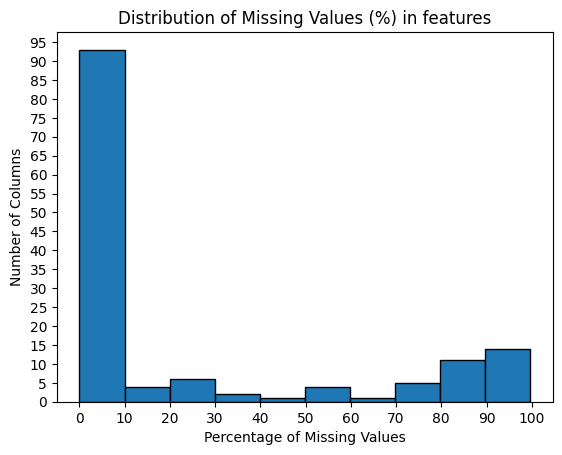

In [48]:
plt.hist(summary["missing_%"], bins=10, edgecolor='black')
plt.title("Distribution of Missing Values (%) in features")
plt.xlabel("Percentage of Missing Values")
plt.ylabel("Number of Columns")
plt.xticks(np.arange(0, 101, 10))
plt.yticks(np.arange(0, 100, 5))
plt.show()

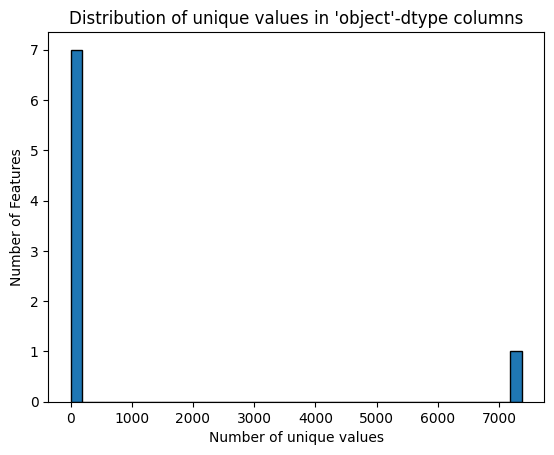

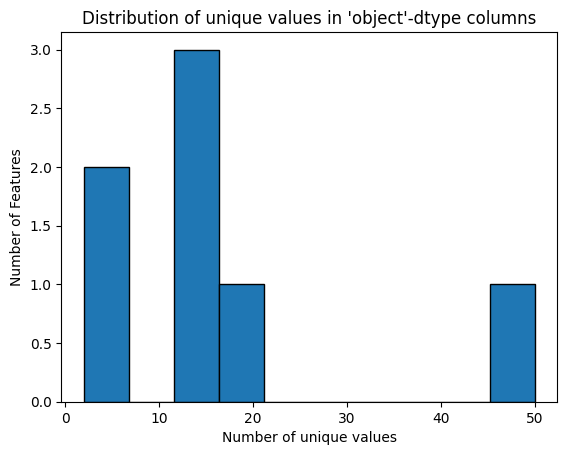

In [ ]:


plt.hist(summary[(summary["missing_%"] < 10) & (summary["dtype"] == "object")]["unique"], bins=40, edgecolor='black')
plt.title("Distribution of unique values in 'object'-dtype columns")
plt.xlabel("Number of unique values")
plt.ylabel("Number of Features")

plt.show()

plt.hist(summary[(summary["missing_%"] < 10) & (summary["dtype"] == "object") & (summary["unique"] <= 100)]["unique"], bins=10, edgecolor='black')
plt.title("Distribution of unique values in 'object'-dtype columns")
plt.xlabel("Number of unique values")
plt.ylabel("Number of Features")
plt.show()

In [58]:
summary[(summary["missing_%"] < 10) & (summary["dtype"] == "object") & (summary["unique"] <= 100)]

,dtype,count,missing,missing_%,unique,min,mean,median,max
genderId,object,7371,0,0.00,2,NaN,NaN,NaN,NaN
orgRef,object,7371,0,0.00,50,NaN,NaN,NaN,NaN
nationality,object,7371,0,0.00,16,NaN,NaN,NaN,NaN
preferredTransport,object,7065,306,4.15,18,NaN,NaN,NaN,NaN
pers-dat-sprach-mutt,object,7270,101,1.37,14,NaN,NaN,NaN,NaN
admin-betr-gsber,object,7371,0,0.00,5,NaN,NaN,NaN,NaN
pflegestatus-paket,object,6754,617,8.37,12,NaN,NaN,NaN,NaN


In [57]:
df["orgRef"].value_counts()

orgRef
Sonstiges                     1420
Team Rumänien                 1236
Team Ungarn                    780
ZZ_Palaloga rum.               505
Team Bulgarien                 479
Direktbewerbung                379
Lescan Daniel                  294
Team Ukraine                   219
Pflege aktiv 24                190
Miljenovic Jasna               181
ZZ_ISL Übernahme               159
Team Slowakei                  151
Petrovcinova Danka             145
HC24 Übernahme                 144
ZZ_Fartunova bulg.             138
Vasilescu Heidi                126
IVA Übernahme                  119
ZZ_PML Übernahme                83
ZZ_Rodlauer Übernahme           83
Banuc rum.                      61
Senecura Übernahme              55
ZZ_Dobanici rum.                46
ZZ_Leshtakova bulg.             41
Pflegegruppe Übernahme          40
Sensivita Übernahme             36
ZZ_Tomek pol.                   34
ZZ_Marzena Belkameh             32
ZZ-_Alexan rum.                 26
ZZ_Second Lif

In [53]:
df[summary[(summary["missing_%"] < 10) & (summary["dtype"] == "object") & (summary["unique"] <= 25)].index]

,genderId,nationality,preferredTransport,pers-dat-sprach-mutt,admin-betr-gsber,pflegestatus-paket
0,F,Rumänien,Sonstiges,Rumänisch,CD24,ZZ_Pflegerin
1,F,Rumänien,Blagoiescu,Rumänisch,CD24,Diplomierte Fachkraft
2,F,Rumänien,Blagoiescu,Rumänisch,CD24,Klassik
3,F,Österreich,ZZ_Cotrans,Rumänisch,CD24,Klassik
4,F,Slowakei,Selbstfahrer,Slowakisch,Geschäftsbereich PML,Premium
...,...,...,...,...,...,...
7366,F,Rumänien,Master Express,Rumänisch,CD24,Basis
7367,F,Rumänien,Blagoiescu,Rumänisch,CD24,CD Perle
7368,F,Rumänien,Master Express,Ungarisch,CD24,Premium
7369,F,Ungarn,Selbstfahrer,Ungarisch,CD24,NaN
